## Import Required Libraries

This section imports the essential Python libraries required for data processing, visualization, and machine learning modeling.

Libraries such as **pandas** and **numpy** are used for data manipulation, **matplotlib** for visualization, and **scikit-learn** for building predictive models. These tools provide the foundation for performing time-series feature engineering and model evaluation.

In [3]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PM25_PATH = Path("../../data/validated/PM25_cityday.csv")
NO2_PATH  = Path("../../data/validated/NO2_cityday.csv")

## Standardizing City Names


In [4]:
def clean_city(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    s = unicodedata.normalize("NFKC", s)   
    s = s.replace("\u00A0", " ")           
    s = " ".join(s.split())             
    return s

pm25 = pd.read_csv(PM25_PATH)
no2  = pd.read_csv(NO2_PATH)

pm25.columns = pm25.columns.str.strip()
no2.columns  = no2.columns.str.strip()

pm25["City"] = pm25["City"].map(clean_city)
no2["City"]  = no2["City"].map(clean_city)

pm25["Date"] = pd.to_datetime(pm25["Date"], errors="coerce").dt.floor("D")
no2["Date"]  = pd.to_datetime(no2["Date"], errors="coerce").dt.floor("D")

pm25 = pm25.dropna(subset=["City","Date"])
no2  = no2.dropna(subset=["City","Date"])

print("PM2.5 shape:", pm25.shape)
print("NO2 shape:", no2.shape)

PM2.5 shape: (256216, 5)
NO2 shape: (232952, 5)


In [5]:
pm25 = pm25.groupby(["City","Date"], as_index=False)["PM25_daily"].mean()
no2  = no2.groupby(["City","Date"], as_index=False)["NO2_daily"].mean()

print("PM2.5 cities:", pm25["City"].nunique())
print("NO2 cities:", no2["City"].nunique())

PM2.5 cities: 185
NO2 cities: 156


## Merging PM2.5 and NO₂ Datasets


In [13]:
merged ["Date"] = pd.to_datetime(merged["Date"])

## Sorting Dataset by City and Date


In [14]:
merged = merged.sort_values(["City", "Date"])

## Enforcing Daily Time Frequency

In [ ]:
merged = (
    merged.set_index("Date")
          .groupby("City", group_keys=False)
          .apply(lambda x: x.asfreq("D"))
          .reset_index()
)
print("Daily frequency enforced successfully.")
print("Dataset shape:", merged.shape)

Daily frequency enforced successfully.
Dataset shape: (156585, 4)


C:\Users\Jaya\AppData\Local\Temp\ipykernel_30928\44466322.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.asfreq("D"))


## Missing Value Assessment


In [10]:
merged.isna().sum()

City          0
Date          0
PM25_daily    0
NO2_daily     0
dtype: int64

In [15]:
merged = pd.merge(pm25, no2, on=["City","Date"], how="inner").sort_values(["City","Date"])

print("Common cities:", merged["City"].nunique())
print("Merged rows:", len(merged))
print("Date range:", merged["Date"].min(), "→", merged["Date"].max())

merged.head()

Common cities: 145
Merged rows: 151711
Date range: 2020-02-18 00:00:00 → 2023-12-31 00:00:00


,City,Date,PM25_daily,NO2_daily
0,Agassiz,2021-01-01,2.666667,7.208333
1,Agassiz,2021-01-02,1.666667,8.083333
2,Agassiz,2021-01-03,3.708333,11.916667
3,Agassiz,2021-01-04,2.250000,9.583333
4,Agassiz,2021-01-05,2.916667,12.750000


## Creating Lag Features

In [18]:
model_df = merged.copy().sort_values(["City","Date"])

for lag in [1, 3, 7]:
    model_df[f"PM25_lag{lag}"] = model_df.groupby("City")["PM25_daily"].shift(lag)

for lag in [1, 3, 7]:
    model_df[f"NO2_lag{lag}"] = model_df.groupby("City")["NO2_daily"].shift(lag)

model_df = model_df.dropna().reset_index(drop=True)
model_df.head()

,City,Date,PM25_daily,NO2_daily,PM25_lag1,PM25_lag3,PM25_lag7,NO2_lag1,NO2_lag3,NO2_lag7
0,Agassiz,2021-01-08,5.250000,8.583333,3.458333,2.916667,2.666667,6.375000,12.750000,7.208333
1,Agassiz,2021-01-09,2.458333,5.416667,5.250000,3.250000,1.666667,8.583333,11.708333,8.083333
2,Agassiz,2021-01-10,3.541667,6.583333,2.458333,3.458333,3.708333,5.416667,6.375000,11.916667
3,Agassiz,2021-01-11,1.666667,7.541667,3.541667,5.250000,2.250000,6.583333,8.583333,9.583333
4,Agassiz,2021-01-12,1.166667,6.625000,1.666667,2.458333,2.916667,7.541667,5.416667,12.750000


Lag features introduce historical information into the predictive models. Since air pollution often shows temporal persistence, previous pollution levels can provide valuable signals for predicting future PM2.5 concentrations.

## Train/Test Split

In [37]:
cutoff = pd.Timestamp("2023-01-01")
train_df = model_df[model_df["Date"] < cutoff].copy()
test_df  = model_df[model_df["Date"] >= cutoff].copy()

print("Train:", train_df["Date"].min(), "→", train_df["Date"].max(), "rows:", len(train_df))
print("Test :", test_df["Date"].min(),  "→", test_df["Date"].max(),  "rows:", len(test_df))
print("Train cities:", train_df["City"].nunique())
print("Test cities :", test_df["City"].nunique())

Train: 2020-02-25 00:00:00 → 2022-12-31 00:00:00 rows: 101108
Test : 2023-01-01 00:00:00 → 2023-12-31 00:00:00 rows: 49588
Train cities: 144
Test cities : 143


A time-based split prevents information from the future leaking into the training process. This ensures that the model evaluation reflects realistic predictive performance when forecasting future pollution levels.

## city dummy variables

In [38]:
city_train = pd.get_dummies(train_df["City"], prefix="City", drop_first=True)
city_test  = pd.get_dummies(test_df["City"], prefix="City", drop_first=True)

city_train, city_test = city_train.align(city_test, join="left", axis=1, fill_value=0)

print("City dummy columns:", city_train.shape[1])

City dummy columns: 143


## Defining Model Features

In [40]:
base_features = ["PM25_lag1", "PM25_lag3", "PM25_lag7"]
no2_features  = base_features + ["NO2_lag1", "NO2_lag3", "NO2_lag7"]

y_train = train_df["PM25_daily"]
y_test  = test_df["PM25_daily"]

X_train_base = pd.concat([train_df[base_features], city_train], axis=1)
X_test_base  = pd.concat([test_df[base_features], city_test], axis=1)

X_train_no2 = pd.concat([train_df[no2_features], city_train], axis=1)
X_test_no2  = pd.concat([test_df[no2_features], city_test], axis=1)

print("Baseline feature shape:", X_train_base.shape)
print("NO2 model feature shape:", X_train_no2.shape)

Baseline feature shape: (101108, 146)
NO2 model feature shape: (101108, 149)


This feature design enables testing of the project hypothesis that incorporating secondary pollutants such as NO₂ can improve PM2.5 prediction accuracy.

## Model Evaluation Metrics


In [16]:
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## Naive baseline model

In [42]:
pred_naive = test_df["PM25_lag1"].values

naive_mae, naive_rmse, naive_r2 = metrics(y_test, pred_naive)

print(f"Naive baseline -> MAE={naive_mae:.3f}, RMSE={naive_rmse:.3f}, R2={naive_r2:.3f}")

Naive baseline -> MAE=5.170, RMSE=16.115, R2=0.321


The naive baseline model predicts PM2.5 using the previous day's value. The model achieved an **MAE of 5.170**, **RMSE of 16.115**, and **R² of 0.321**, meaning that about **32.1% of the variation in PM2.5 levels is explained by the previous day's pollution level**.

While the model captures some short-term persistence in pollution levels, the moderate R² value indicates that additional factors are needed to improve prediction accuracy. This baseline serves as a benchmark for evaluating more advanced models.

## Linear regression models

In [43]:
m_base = LinearRegression()
m_base.fit(X_train_base, y_train)
pred_base = m_base.predict(X_test_base)

m_no2 = LinearRegression()
m_no2.fit(X_train_no2, y_train)
pred_no2 = m_no2.predict(X_test_no2)

base_mae, base_rmse, base_r2 = metrics(y_test, pred_base)
no2_mae, no2_rmse, no2_r2 = metrics(y_test, pred_no2)

print(f"Linear: PM25 lags only      -> MAE={base_mae:.3f}, RMSE={base_rmse:.3f}, R2={base_r2:.3f}")
print(f"Linear: PM25 + NO2 lags     -> MAE={no2_mae:.3f}, RMSE={no2_rmse:.3f}, R2={no2_r2:.3f}")

Linear: PM25 lags only      -> MAE=4.669, RMSE=14.657, R2=0.438
Linear: PM25 + NO2 lags     -> MAE=4.671, RMSE=14.651, R2=0.439


The linear regression models were trained using lagged PM2.5 variables, with and without NO₂ lag features.

Both models show improved performance compared to the naive baseline, with RMSE decreasing from **16.115** to approximately **14.65** and R² increasing from **0.321** to about **0.44**. 

This indicates that incorporating multiple lag features allows the model to capture temporal patterns in PM2.5 more effectively. Adding NO₂ variables results in only a **very small improvement**, suggesting that NO₂ contributes limited additional predictive information in this linear modeling framework.

## Random Forest model

In [44]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_no2, y_train)
pred_rf = rf.predict(X_test_no2)

rf_mae, rf_rmse, rf_r2 = metrics(y_test, pred_rf)

print(f"Random Forest: PM25 + NO2  -> MAE={rf_mae:.3f}, RMSE={rf_rmse:.3f}, R2={rf_r2:.3f}")

Random Forest: PM25 + NO2  -> MAE=4.755, RMSE=14.853, R2=0.423


The Random Forest model was used to capture nonlinear relationships between PM2.5 and its predictors. 

The model achieved an RMSE of **14.853** and an R² of **0.423**, which is slightly worse than the linear regression models. This suggests that, for this dataset, the relationship between the predictors and PM2.5 is largely linear and does not benefit significantly from a more complex nonlinear model.

## Model comparison table

In [45]:
results = pd.DataFrame({
    "Model": [
        "Naive_PM25_lag1",
        "Linear_PM25_Lags",
        "Linear_PM25_Lags_+_NO2_Lags",
        "RandomForest_PM25_Lags_+_NO2_Lags"
    ],
    "MAE": [naive_mae, base_mae, no2_mae, rf_mae],
    "RMSE": [naive_rmse, base_rmse, no2_rmse, rf_rmse],
    "R2": [naive_r2, base_r2, no2_r2, rf_r2]
})

results = results.sort_values("RMSE").reset_index(drop=True)
results

,Model,MAE,RMSE,R2
0,Linear_PM25_Lags_+_NO2_Lags,4.670889,14.650658,0.438770
1,Linear_PM25_Lags,4.669213,14.656581,0.438316
2,RandomForest_PM25_Lags_+_NO2_Lags,4.755245,14.853018,0.423159
3,Naive_PM25_lag1,5.170066,16.114940,0.320978


The model comparison table shows that the **Linear Regression model with PM2.5 and NO₂ lag features** achieved the best performance, with the lowest RMSE and highest R².

Compared to the naive baseline model, all machine learning models significantly reduce prediction error. The results indicate that incorporating multiple lag features improves PM2.5 prediction accuracy.

However, the improvement from adding NO₂ variables is relatively small, suggesting that historical PM2.5 levels remain the most important predictors in this dataset.

## Improvement check for Hypothesis 3

In [ ]:
improvement_rmse = base_rmse - no2_rmse
improvement_mae = base_mae - no2_mae

print("Improvement after adding NO2:")
print(f"RMSE improvement: {improvement_rmse:.3f}")
print(f"MAE improvement : {improvement_mae:.3f}")

Improvement after adding NO2:
RMSE improvement: 0.006
MAE improvement : -0.002


The improvement check evaluates whether adding NO₂ features improves PM2.5 prediction.

The results show a **very small RMSE improvement of 0.006**, while MAE slightly decreases by **-0.002**, indicating negligible overall improvement. 

This suggests that NO₂ provides **only limited additional predictive value** for PM2.5 forecasting in this dataset.

## Actual vs predicted plot

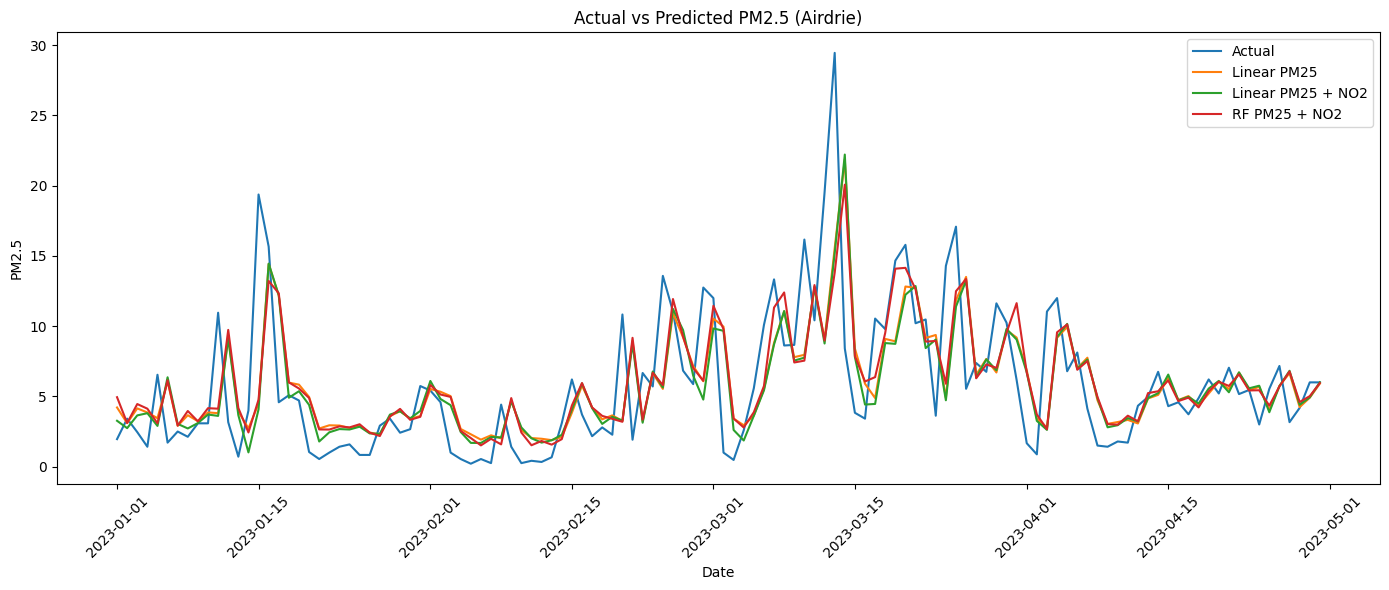

In [ ]:
sample_plot = test_df[["Date", "City", "PM25_daily"]].copy()
sample_plot["Pred_Linear_PM25"] = pred_base
sample_plot["Pred_Linear_PM25_NO2"] = pred_no2
sample_plot["Pred_RF_PM25_NO2"] = pred_rf

top_city = sample_plot["City"].value_counts().idxmax()
plot_df = sample_plot[sample_plot["City"] == top_city].sort_values("Date").head(120)

plt.figure(figsize=(14, 6))
plt.plot(plot_df["Date"], plot_df["PM25_daily"], label="Actual")
plt.plot(plot_df["Date"], plot_df["Pred_Linear_PM25"], label="Linear PM25")
plt.plot(plot_df["Date"], plot_df["Pred_Linear_PM25_NO2"], label="Linear PM25 + NO2")
plt.plot(plot_df["Date"], plot_df["Pred_RF_PM25_NO2"], label="RF PM25 + NO2")

plt.title(f"Actual vs Predicted PM2.5 ({top_city})")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

file_path = output_dir / "PM25_NO2_model_comparison.csv"
results.to_csv(file_path, index=False)

print("Saved to:", file_path)

Saved to: results\PM25_NO2_model_comparison.csv
